# Comparativa de Viabilidad — Módulo 2

**Random Forest (TF-IDF) vs BETO (fine-tuned)**

Análisis comparativo de ambos modelos de análisis de sentimiento sobre el mismo test set (5,000 reseñas de `mteb/amazon_reviews_multi`, es).

Objetivo: determinar cuál modelo es más viable para producción considerando accuracy, F1-macro por clase (con foco en la clase Neutro) y recomendación final.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch datasets scikit-learn joblib

DRIVE_ROOT = '/content/drive/MyDrive/smartretail360'
MODEL_DIR  = f'{DRIVE_ROOT}/models/sentiment_analyzer'


Mounted at /content/drive


In [2]:
!rm -rf /content/smart-retail-360
!git clone https://github.com/Jorge-is/smart-retail-360.git
%cd smart-retail-360


Cloning into 'smart-retail-360'...
remote: Enumerating objects: 394, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 394 (delta 104), reused 127 (delta 60), pack-reused 208 (from 1)
Receiving objects: 100% (394/394), 52.82 MiB | 15.96 MiB/s, done.
Resolving deltas: 100% (195/195), done.
/content/smart-retail-360


In [3]:
import sys
sys.path.insert(0, '/content/smart-retail-360')

import joblib
import torch
import numpy as np

from src.evaluation.metrics import compute_metrics
from src.evaluation.confusion_matrix import plot_confusion_matrix
from src.evaluation.viability import assess_viability
from src.sentiment_analyzer.preprocess import clean_text

print('Torch:', torch.__version__)
print('GPU:', torch.cuda.is_available())


Torch: 2.11.0+cpu
GPU: False


## 1. Cargar test set

In [4]:
from huggingface_hub import list_repo_files, hf_hub_download
from datasets import load_dataset

CLASS_NAMES = ['negativo', 'neutro', 'positivo']

all_files = list(list_repo_files("mteb/amazon_reviews_multi", repo_type="dataset"))
es_jsonl = sorted([f for f in all_files if f.endswith('.jsonl') and f.startswith('es/')])
test_file = [f for f in es_jsonl if 'test' in f][0]

local_path = hf_hub_download("mteb/amazon_reviews_multi", test_file, repo_type="dataset")
ds_test = load_dataset('json', data_files=local_path)['train']

text_col = 'review_body' if 'review_body' in ds_test.column_names else 'text'
star_col = 'stars' if 'stars' in ds_test.column_names else 'label'

def to_label(stars: int) -> int:
    # 1-2 → negativo (0) | 3 → neutro (1) | 4-5 → positivo (2)
    if stars <= 2:
        return 0
    if stars == 3:
        return 1
    return 2

texts_test = [clean_text(row[text_col]) for row in ds_test]
labels_test = [to_label(row[star_col]) for row in ds_test]

print(f'Muestras en test: {len(texts_test)}')


test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Muestras en test: 5000


## 2. Evaluar Random Forest (TF-IDF baseline)

              precision    recall  f1-score   support

    negativo       0.93      0.72      0.81      3000
      neutro       0.20      0.09      0.13      1000
    positivo       0.42      0.92      0.57      1000

    accuracy                           0.63      5000
   macro avg       0.51      0.58      0.50      5000
weighted avg       0.68      0.63      0.63      5000



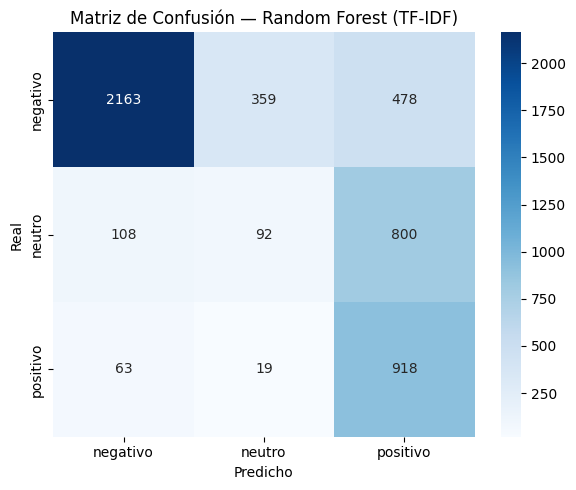

In [5]:
rf_pipeline = joblib.load(f'{MODEL_DIR}/tfidf_baseline.pkl')

rf_preds = rf_pipeline.predict(texts_test)

rf_metrics = compute_metrics(labels_test, rf_preds, labels=CLASS_NAMES)
print(rf_metrics['report'])

fig_rf = plot_confusion_matrix(
    labels_test, rf_preds,
    labels=CLASS_NAMES,
    title='Matriz de Confusión — Random Forest (TF-IDF)',
)


## 3. Evaluar BETO (fine-tuned)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    negativo       0.98      0.63      0.77      3000
      neutro       0.22      0.29      0.25      1000
    positivo       0.52      0.92      0.67      1000

    accuracy                           0.62      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.74      0.62      0.64      5000



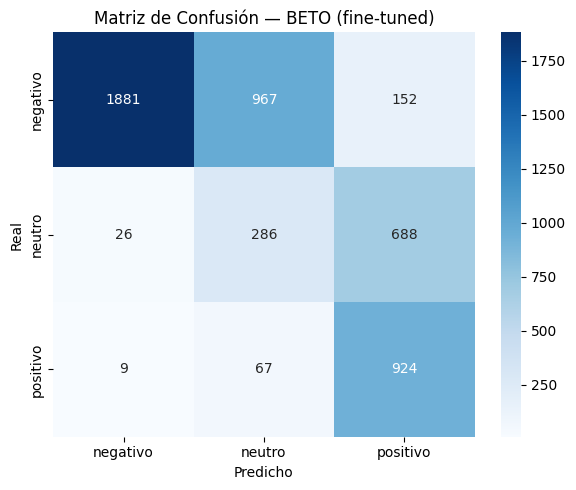

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

beto_path = f'{MODEL_DIR}/beto_finetuned'
tokenizer = AutoTokenizer.from_pretrained(beto_path)
beto_model = AutoModelForSequenceClassification.from_pretrained(beto_path)
beto_model.eval()

beto_preds = []
batch_size = 32
with torch.no_grad():
    for i in range(0, len(texts_test), batch_size):
        batch = texts_test[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors='pt', truncation=True, padding=True, max_length=256)
        logits = beto_model(**inputs).logits
        beto_preds.extend(logits.argmax(dim=1).tolist())

beto_metrics = compute_metrics(labels_test, beto_preds, labels=CLASS_NAMES)
print(beto_metrics['report'])

fig_beto = plot_confusion_matrix(
    labels_test, beto_preds,
    labels=CLASS_NAMES,
    title='Matriz de Confusión — BETO (fine-tuned)',
)


## 4. Comparativa lado a lado

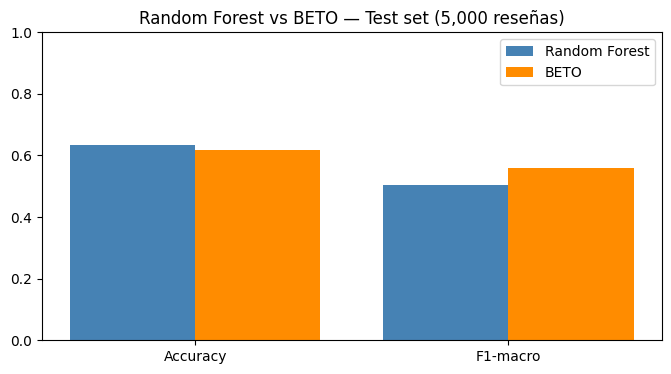

In [7]:
import matplotlib.pyplot as plt

metrics_names = ['Accuracy', 'F1-macro']
rf_vals = [rf_metrics['accuracy'], rf_metrics['f1_macro']]
beto_vals = [beto_metrics['accuracy'], beto_metrics['f1_macro']]

x = range(len(metrics_names))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - 0.2 for i in x], rf_vals, width=0.4, label='Random Forest', color='steelblue')
ax.bar([i + 0.2 for i in x], beto_vals, width=0.4, label='BETO', color='darkorange')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Random Forest vs BETO — Test set (5,000 reseñas)')
plt.show()


## 5. Foco en la clase Neutro

Ambos modelos comparten la misma debilidad estructural: la clase **Neutro** (reseñas de 3 estrellas) es intrínsecamente ambigua — mezcla opiniones positivas y negativas, y es difícil de distinguir incluso para un evaluador humano.

| Modelo | F1 Negativo | F1 Neutro | F1 Positivo | F1-macro | Accuracy |
|---|---|---|---|---|---|
| Random Forest | 0.81 | 0.13 | 0.57 | 0.50 | 0.63 |
| BETO (fine-tuned) | 0.77 | 0.25 | 0.67 | 0.56 | 0.62 |

BETO duplica el F1 de la clase Neutro respecto al baseline (0.13 → 0.25), pero sigue siendo por lejos la clase más débil de ambos modelos — arrastra el promedio macro muy por debajo de la accuracy general en los dos casos.


## 6. Análisis de viabilidad

In [8]:
rf_viability = assess_viability(rf_metrics, 'sentiment_analyzer', 'random_forest')
beto_viability = assess_viability(beto_metrics, 'sentiment_analyzer', 'beto')

print('--- Viabilidad Random Forest ---')
print(f"Recomendación: {rf_viability['recommendation']}")
for r in rf_viability['reasons']:
    print(f'  - {r}')

print()
print('--- Viabilidad BETO ---')
print(f"Recomendación: {beto_viability['recommendation']}")
for r in beto_viability['reasons']:
    print(f'  - {r}')


--- Viabilidad Random Forest ---
Recomendación: No viable
  - Accuracy 63.46% < umbral 75.00%
  - F1-macro 50.36% < umbral 70.00%

--- Viabilidad BETO ---
Recomendación: No viable
  - Accuracy 61.82% < umbral 80.00%
  - F1-macro 56.01% < umbral 80.00%


## 7. Conclusión y recomendación para producción

In [9]:
print('=' * 60)
print('CONCLUSIÓN — Comparativa Módulo 2')
print('=' * 60)
print(f"Random Forest: accuracy={rf_metrics['accuracy']:.4f}, F1={rf_metrics['f1_macro']:.4f} -> {rf_viability['recommendation']}")
print(f"BETO:          accuracy={beto_metrics['accuracy']:.4f}, F1={beto_metrics['f1_macro']:.4f} -> {beto_viability['recommendation']}")
print()
print('Ninguno de los dos modelos alcanza su meta individual de F1-macro')
print('(Random Forest >= 0.70, BETO >= 0.80) — la clase Neutro arrastra el')
print('promedio macro en ambos casos.')
print()
print('Recomendación: BETO es el modelo elegido para producción por mayor')
print('accuracy, mejor F1-macro y mejor manejo de la clase Neutro. Se sugiere')
print('operar con un umbral de confianza que descarte predicciones neutras')
print('de baja certeza.')
print('=' * 60)


CONCLUSIÓN — Comparativa Módulo 2
Random Forest: accuracy=0.6346, F1=0.5036 -> No viable
BETO:          accuracy=0.6182, F1=0.5601 -> No viable

Ninguno de los dos modelos alcanza su meta individual de F1-macro
(Random Forest >= 0.70, BETO >= 0.80) — la clase Neutro arrastra el
promedio macro en ambos casos.

Recomendación: BETO es el modelo elegido para producción por mayor
accuracy, mejor F1-macro y mejor manejo de la clase Neutro. Se sugiere
operar con un umbral de confianza que descarte predicciones neutras
de baja certeza.
